# ResNet1D RF Modulation Classification

## Approach
MATLAB signal → Normalize I/Q → 1D ResNet

## Key Advantages
- No CWT computation (much faster preprocessing)
- Smaller model (~2.5M params vs 11M for ResNet18)
- 3-4x faster training
- Direct learning from raw I/Q samples

## Section 1: Setup and Imports

In [1]:
# Clear GPU memory before starting 
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"GPU memory freed. Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CUDA not available, using CPU")

GPU memory freed. Available: 8.6 GB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matlab.engine
import time
from pathlib import Path
import sys
import json

# NOTE: ResNet1D classes defined inline later (no external import needed)

%matplotlib inline

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Section 2: MATLAB Signal Generation

In [3]:
# Start MATLAB engine
print("Starting MATLAB engine...")
eng = matlab.engine.start_matlab()
print("MATLAB ready!")

modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']

Starting MATLAB engine...
MATLAB ready!


In [4]:
def generate_signal(eng, mod_type, snr_db=10, num_symbols=1000):
    """
    Generate modulated signal with Pulse Shaping (RRC) for PSK/QAM
    to create realistic time-domain waveforms.
    """
    # Common params for Pulse Shaping
    eng.eval("sps = 8;", nargout=0)  # Samples per symbol (Oversampling)
    eng.eval("rolloff = 0.35;", nargout=0)
    eng.eval("span = 10;", nargout=0)
    eng.eval("rrcFilter = rcosdesign(rolloff, span, sps);", nargout=0)

    if mod_type == 'BPSK':
        eng.eval(f"data = randi([0 1], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 2);", nargout=0)
        # Apply Pulse Shaping to turn dots into wave
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == 'QPSK':
        eng.eval(f"data = randi([0 3], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 4, pi/4);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '8PSK':
        eng.eval(f"data = randi([0 7], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = pskmod(data, 8);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '16QAM':
        eng.eval(f"data = randi([0 15], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = qammod(data, 16, 'UnitAveragePower', true);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '64QAM':
        eng.eval(f"data = randi([0 63], {num_symbols}, 1);", nargout=0)
        eng.eval("mod_sig = qammod(data, 64, 'UnitAveragePower', true);", nargout=0)
        eng.eval("tx = upfirdn(mod_sig, rrcFilter, sps);", nargout=0)
    
    elif mod_type == '4FSK':
        # FSK is already a waveform (nsamp=16), no change needed
        eng.eval("M = 4; nsamp = 16; freq_sep = 50; Fs_fsk = 1000;", nargout=0)
        eng.eval(f"data = randi([0 M-1], {num_symbols//16}, 1);", nargout=0)
        eng.eval("tx = fskmod(data, M, freq_sep, nsamp, Fs_fsk);", nargout=0)
    
    elif mod_type == 'OFDM':
        # OFDM is already a waveform, no change needed
        eng.eval("ofdm_mod = comm.OFDMModulator('FFTLength', 64, 'CyclicPrefixLength', 16);", nargout=0)
        eng.eval("ofdm_info = info(ofdm_mod);", nargout=0)
        eng.eval("num_carriers = ofdm_info.DataInputSize(1);", nargout=0)
        eng.eval(f"num_symbols = {num_symbols // 80};", nargout=0)
        eng.eval("tx = [];", nargout=0)
        eng.eval("for k = 1:num_symbols; d = pskmod(randi([0 3], num_carriers, 1), 4, pi/4); tx = [tx; ofdm_mod(d)]; end", nargout=0)
    
    # Add noise
    eng.eval(f"rx = awgn(tx, {snr_db}, 'measured');", nargout=0)
    
    # Get signal
    rx = np.array(eng.workspace['rx']).flatten()
    return rx

## Section 3: 1D Preprocessing

In [5]:
def prepare_1d_signal(signal, target_length=2048):
    """
    Fixed: Normalizes by Global Power to preserve constellation shape.
    """
    # 1. Truncate/Pad
    if len(signal) > target_length:
        signal = signal[:target_length]
    elif len(signal) < target_length:
        signal = np.pad(signal, (0, target_length - len(signal)), mode='constant')
    
    # 2. Extract I/Q
    I = signal.real
    Q = signal.imag
    
    # 3. Normalization 
    # Calculate power of the complex signal, not individual channels
    power = np.sqrt(np.mean(I**2 + Q**2))
    
    # Avoid division by zero
    if power < 1e-10: 
        power = 1e-10
        
    I = I / power
    Q = Q / power
    
    # Stack
    return np.stack([I, Q], axis=0).astype(np.float32)

## Section 4: Visualize Sample Signals

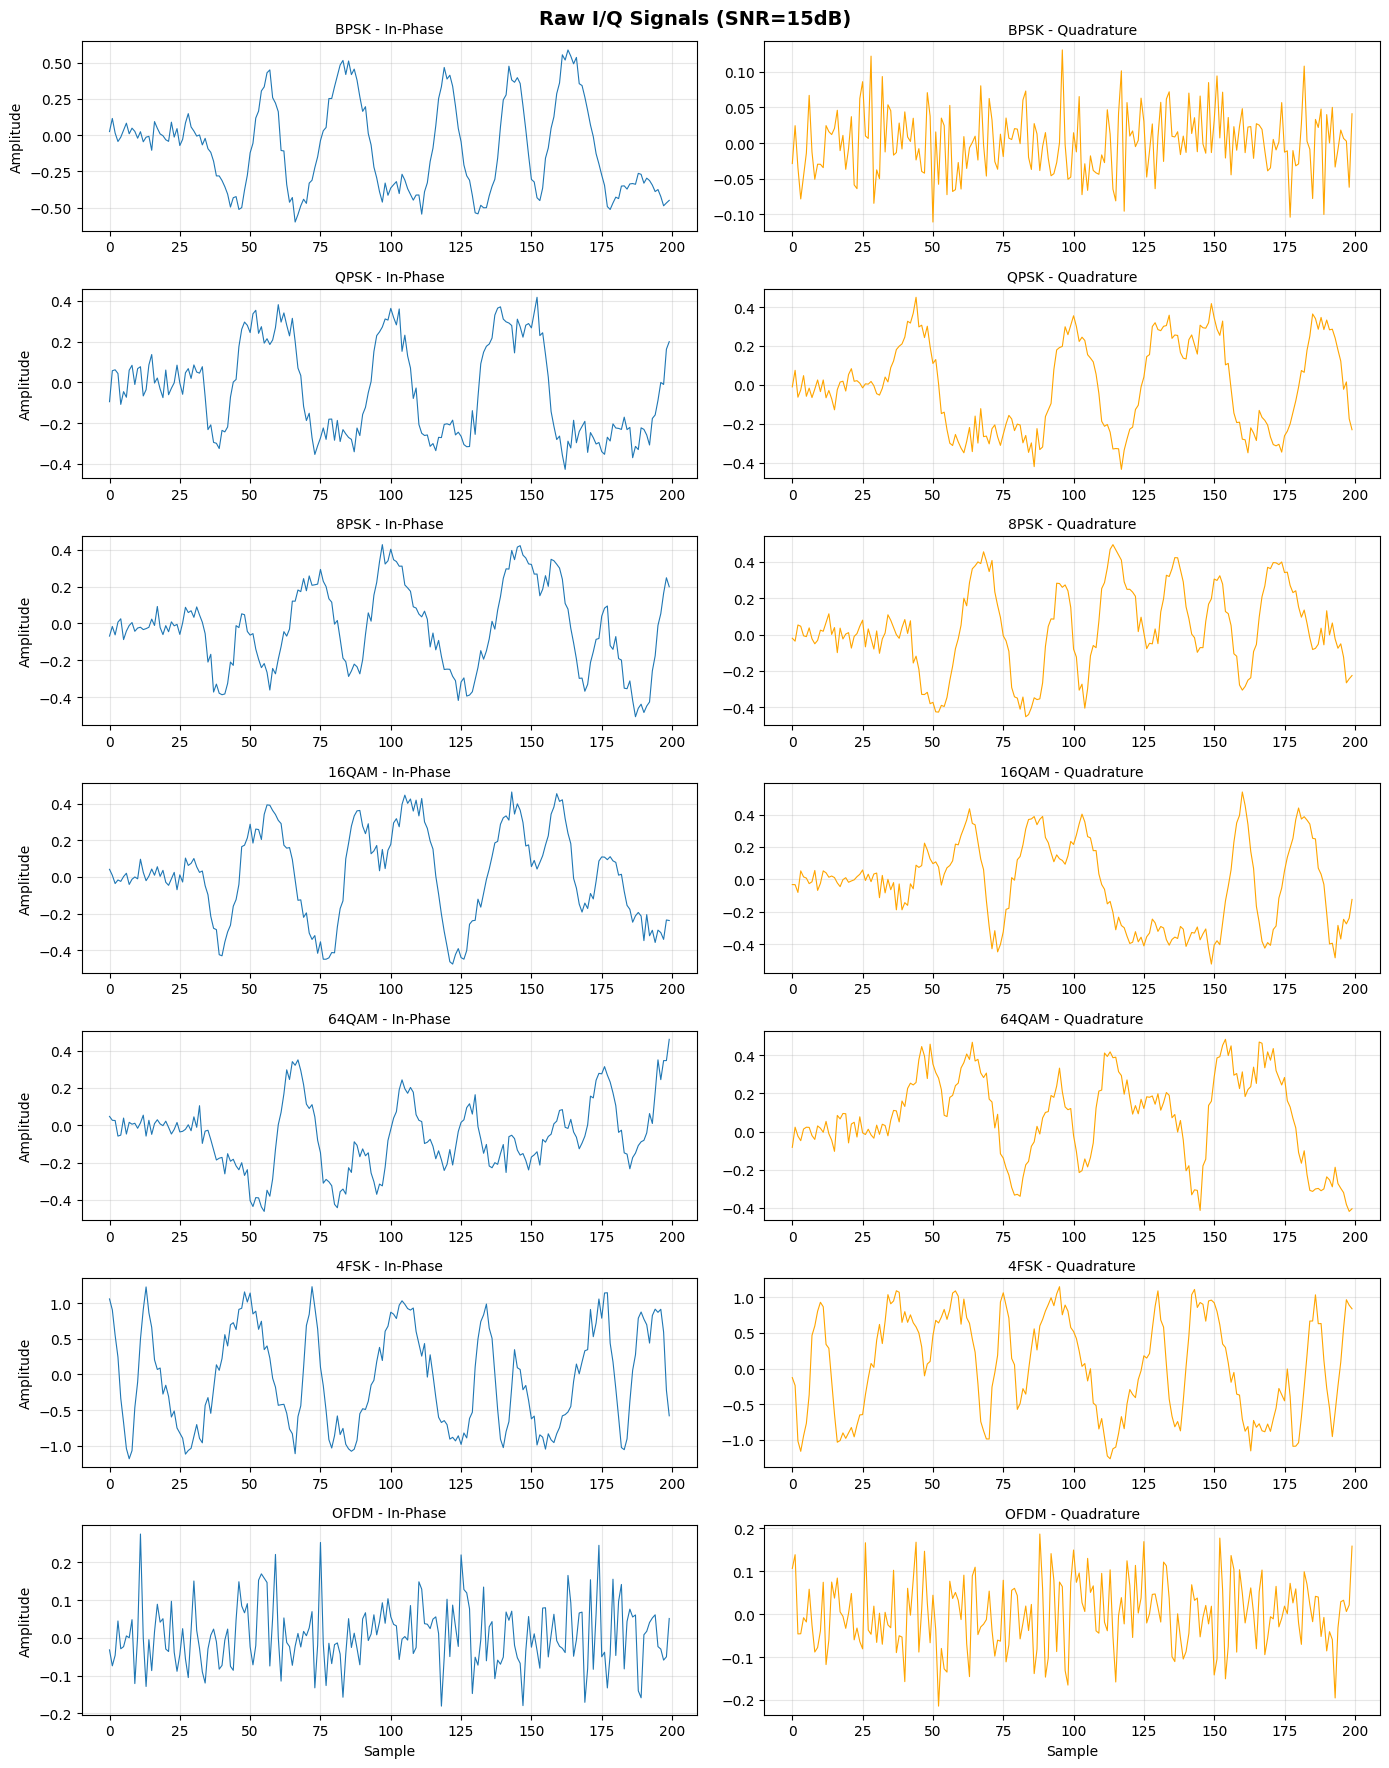

In [6]:
# Generate and visualize test signals
fig, axes = plt.subplots(len(modulations), 2, figsize=(14, 18))

for idx, mod in enumerate(modulations):
    signal = generate_signal(eng, mod, snr_db=15, num_symbols=1000)
    
    # Plot I (real) component
    axes[idx, 0].plot(signal[:200].real, linewidth=0.8)
    axes[idx, 0].set_title(f'{mod} - In-Phase', fontsize=10)
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot Q (imaginary) component
    axes[idx, 1].plot(signal[:200].imag, linewidth=0.8, color='orange')
    axes[idx, 1].set_title(f'{mod} - Quadrature', fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Sample')
axes[-1, 1].set_xlabel('Sample')
plt.suptitle('Raw I/Q Signals (SNR=15dB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5: Dataset Class

In [7]:
class Signal1DDataset(Dataset):
    def __init__(self, signals, labels):
        """
        signals: numpy array of shape [N, 2, L] (2 channels: I and Q)
        labels: numpy array of shape [N]
        """
        self.signals = signals
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        signal = self.signals[idx]
        label = self.labels[idx]
        
        return torch.from_numpy(signal).float(), torch.tensor(label, dtype=torch.long)

## Section 6: Generate Dataset

In [8]:
NUM_SAMPLES_PER_CLASS = 1000
SIGNAL_LENGTH = 2048

print(f"Generating dataset: {NUM_SAMPLES_PER_CLASS} samples/class...")
print(f"Total samples: {NUM_SAMPLES_PER_CLASS * len(modulations)}")

# Storage
signals_1d = []
labels = []

start_time = time.time()

for label_idx, mod in enumerate(modulations):
    print(f"  {mod}...")
    
    for i in range(NUM_SAMPLES_PER_CLASS):
        if i % 100 == 0 and i > 0:
            elapsed = time.time() - start_time
            print(f"    {i}/{NUM_SAMPLES_PER_CLASS}... (elapsed: {elapsed:.1f}s)")
        
        # Random SNR between -5 and 20 dB
        # snr = np.random.uniform(-5, 20) maybe -5 was a bit too ambitious 
        snr = np.random.uniform(-5, 20)

        # Generate signal
        signal = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
        
        # 1D preprocessing
        sig_1d = prepare_1d_signal(signal, target_length=SIGNAL_LENGTH)
        signals_1d.append(sig_1d)
        
        labels.append(label_idx)

total_time = time.time() - start_time

# Convert to arrays
signals_1d = np.array(signals_1d, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)

print(f"\n✅ Dataset generated in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"1D signals shape: {signals_1d.shape}")
print(f"Labels shape: {labels.shape}")

Generating dataset: 1000 samples/class...
Total samples: 7000
  BPSK...
    100/1000... (elapsed: 2.1s)
    200/1000... (elapsed: 4.2s)
    300/1000... (elapsed: 6.2s)
    400/1000... (elapsed: 8.3s)
    500/1000... (elapsed: 10.5s)
    600/1000... (elapsed: 12.7s)
    700/1000... (elapsed: 14.8s)
    800/1000... (elapsed: 17.0s)
    900/1000... (elapsed: 19.0s)
  QPSK...
    100/1000... (elapsed: 23.2s)
    200/1000... (elapsed: 26.5s)
    300/1000... (elapsed: 28.6s)
    400/1000... (elapsed: 30.6s)
    500/1000... (elapsed: 32.7s)
    600/1000... (elapsed: 34.8s)
    700/1000... (elapsed: 36.8s)
    800/1000... (elapsed: 38.8s)
    900/1000... (elapsed: 40.8s)
  8PSK...
    100/1000... (elapsed: 45.1s)
    200/1000... (elapsed: 47.2s)
    300/1000... (elapsed: 49.3s)
    400/1000... (elapsed: 51.4s)
    500/1000... (elapsed: 53.7s)
    600/1000... (elapsed: 55.8s)
    700/1000... (elapsed: 57.9s)
    800/1000... (elapsed: 60.0s)
    900/1000... (elapsed: 62.0s)
  16QAM...
    100/10

In [9]:
# Check class balance
class_counts = np.bincount(labels)
print("Class distribution:")
for mod, count in zip(modulations, class_counts):
    print(f"  {mod}: {count} samples ({count/len(labels)*100:.1f}%)")

Class distribution:
  BPSK: 1000 samples (14.3%)
  QPSK: 1000 samples (14.3%)
  8PSK: 1000 samples (14.3%)
  16QAM: 1000 samples (14.3%)
  64QAM: 1000 samples (14.3%)
  4FSK: 1000 samples (14.3%)
  OFDM: 1000 samples (14.3%)


## Section 7: Train/Val Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    signals_1d, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Training: {X_train.shape}, Validation: {X_val.shape}")

Training: (5600, 2, 2048), Validation: (1400, 2, 2048)


In [11]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew

def get_signal_features(X_data, y_data, labels_map):
    """
    Extracts statistical fingerprints from I/Q data.
    X_data: (N, 2, 2048)
    y_data: (N,)
    """
    features = []
    
    indices = np.random.choice(len(X_data), 500, replace=False)
    
    for idx in indices:
        sig = X_data[idx] # Shape (2, 2048)
        
        # Reconstruct complex signal for easier math
        complex_sig = sig[0] + 1j * sig[1]
        
        # 1. Amplitude Statistics
        amp = np.abs(complex_sig)
        papr = np.max(amp**2) / np.mean(amp**2) # Peak-to-Average Power Ratio
        
        # 2. Higher Order Statistics (The "Gold Standard" for Modulation)
        # C42 (4th order cumulant) is great for separating QAM from PSK
        m4 = np.mean(complex_sig**4)
        m2 = np.mean(complex_sig**2)
        c42 = np.mean(np.abs(complex_sig)**4) - np.abs(m2)**2 - 2 * np.mean(np.abs(complex_sig)**2)**2

        features.append({
            'Label': labels_map[y_data[idx]],
            'PAPR': papr,
            'Kurtosis_Real': kurtosis(sig[0]),
            'Kurtosis_Imag': kurtosis(sig[1]),
            'C42': np.abs(c42) 
        })
        
    df = pd.DataFrame(features)
    
    # Group by label to see the "fingerprint" of each modulation
    summary = df.groupby('Label').mean().round(4)
    return summary

# Map numeric labels back to names
label_names = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']
summary_table = get_signal_features(X_train, y_train, label_names)

print(summary_table.to_markdown())

| Label   |    PAPR |   Kurtosis_Real |   Kurtosis_Imag |    C42 |
|:--------|--------:|----------------:|----------------:|-------:|
| 16QAM   |  5.374  |         -0.643  |         -0.641  | 0.3182 |
| 4FSK    |  7.8187 |          1.2539 |          1.2339 | 0.8321 |
| 64QAM   |  5.5355 |         -0.5951 |         -0.6078 | 0.2916 |
| 8PSK    |  4.8965 |         -0.6763 |         -0.6677 | 0.4552 |
| BPSK    |  5.1715 |         -1.083  |          0.0025 | 0.9198 |
| OFDM    | 15.5261 |          3.2783 |          3.3258 | 2.2111 |
| QPSK    |  4.6086 |         -1.0003 |         -1.0175 | 0.4982 |


## Section 7.5: OPTIMIZATION ADDITIONS - Advanced Augmentation & Architecture

This section defines essential classes for improved performance:
- `IQAugmentation` - Advanced data augmentation for RF signals
- `ResNet1DOptimized` - Enhanced model architecture with SE attention
- `Signal1DDatasetAugmented` - Dataset class with augmentation support
- `train_optimized` - Training function with AMP and better scheduling
- `evaluate_with_tta` - Test-time augmentation for accuracy boost

In [12]:
# ============================================
# PART 2: OPTIMIZED RESNET1D ARCHITECTURE
# ============================================

def get_num_groups(num_channels, max_groups=8):
    """Get a valid number of groups that divides num_channels."""
    for g in range(min(max_groups, num_channels), 0, -1):
        if num_channels % g == 0:
            return g
    return 1

class SEBlock1D(nn.Module):
    """Squeeze-Excitation attention block"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, max(channels//reduction, 4), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels//reduction, 4), channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1)
        return x * y

class ResBlock1D(nn.Module):
    """Enhanced residual block with SE attention and GroupNorm"""
    def __init__(self, in_ch, out_ch, kernel_size, stride, downsample, dropout=0.1):
        super().__init__()
        num_groups = get_num_groups(out_ch, max_groups=32)
        padding = (kernel_size - 1) // 2
        
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.gn1 = nn.GroupNorm(num_groups, out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, 1, padding, bias=False)
        self.gn2 = nn.GroupNorm(num_groups, out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.se = SEBlock1D(out_ch)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.gn1(out)
        out = self.relu(out)
        
        if self.dropout:
            out = self.dropout(out)
        
        out = self.conv2(out)
        out = self.gn2(out)
        out = self.se(out)
        
        if self.downsample:
            identity = self.downsample(x)
        
        # FIX: Ensure sizes match exactly (handles rounding issues with stride)
        if out.size(-1) != identity.size(-1):
            identity = nn.functional.adaptive_avg_pool1d(identity, out.size(-1))
        
        out += identity
        return self.relu(out)

class MultiScaleInput(nn.Module):
    """Multi-scale feature extraction with different kernel sizes"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        branch_ch = out_ch // 4
        num_groups = get_num_groups(branch_ch, max_groups=8)
        
        self.b1 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 3, padding=1),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b2 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 7, padding=3),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b3 = nn.Sequential(
            nn.Conv1d(in_ch, branch_ch, 15, padding=7),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
        self.b4 = nn.Sequential(
            nn.AvgPool1d(3, 1, 1),
            nn.Conv1d(in_ch, branch_ch, 1),
            nn.GroupNorm(num_groups, branch_ch),
            nn.ReLU()
        )
    
    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

class ResNet1DOptimized(nn.Module):
    """Optimized ResNet1D with attention and multi-scale features"""
    def __init__(self, in_ch=2, base_filters=64, kernel_size=16, stride=2, n_block=10, n_classes=7, dropout=0.2):
        super().__init__()
        
        # Multi-scale input
        self.input_layer = MultiScaleInput(in_ch, base_filters)
        
        # Residual blocks - only downsample in first few blocks to avoid shrinking too small
        # With stride=2, max ~6 downsamples for 2048 input: 2048→1024→512→256→128→64→32
        max_downsample_blocks = 6  # After this, use stride=1
        
        self.layers = nn.ModuleList()
        in_filters = base_filters
        
        for i in range(n_block):
            out_filters = base_filters * (2 ** (i // 3))  # Double every 3 blocks
            out_filters = min(out_filters, 256)  # Cap at 256
            
            # Only use stride=2 for first max_downsample_blocks, then stride=1
            block_stride = stride if i < max_downsample_blocks else 1
            
            # Downsample if stride > 1 or channel change
            downsample = None
            if block_stride != 1 or in_filters != out_filters:
                ds_num_groups = get_num_groups(out_filters, max_groups=32)
                downsample = nn.Sequential(
                    nn.Conv1d(in_filters, out_filters, 1, block_stride, bias=False),
                    nn.GroupNorm(ds_num_groups, out_filters)
                )
            
            self.layers.append(ResBlock1D(in_filters, out_filters, kernel_size, block_stride, downsample, dropout))
            in_filters = out_filters
        
        # Global pooling and classifier
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(in_filters, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout/2),
            nn.Linear(128, n_classes)
        )
    
    def forward(self, x):
        x = self.input_layer(x)
        for layer in self.layers:
            x = layer(x)
        x = self.gap(x)
        return self.classifier(x)

modulations

# Quick test
test_input = torch.randn(4, 2, SIGNAL_LENGTH).to(device)
test_model = ResNet1DOptimized(n_classes=len(modulations)).to(device)
test_output = test_model(test_input)
print(f"Test output shape: {test_output.shape}")
print(f"Model params: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model, test_input, test_output
torch.cuda.empty_cache()

Test output shape: torch.Size([4, 7])
Model params: 9,868,679


In [13]:
# ============================================
# PART 4: OPTIMIZED TRAINING FUNCTION
# ============================================
import time
from torch.cuda.amp import GradScaler, autocast  # Essential for the 'Optimized' parts

def train_optimized(model, train_loader, val_loader, num_epochs=100, lr=0.001, weight_decay=1e-4, warmup=5, patience=15):
    """Optimized training with AMP, label smoothing, better scheduling"""
    
    model = model.to(device)
    scaler = GradScaler(enabled=torch.cuda.is_available())
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-warmup, eta_min=lr*0.01)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_times': []}
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        start = time.time()
        
        # Warmup
        if epoch < warmup:
            curr_lr = lr * (epoch + 1) / warmup
            for pg in optimizer.param_groups:
                pg['lr'] = curr_lr
        else:
            scheduler.step()
        
        # Train
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            with autocast(enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item() * inputs.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # Validate
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                
                with autocast(enabled=torch.cuda.is_available()):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(targets).sum().item()
                total += targets.size(0)
        
        val_loss /= total
        val_acc = 100.0 * correct / total
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['epoch_times'].append(time.time() - start)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Train: {train_loss:.4f}, Val: {val_loss:.4f}, "
                  f"Acc: {val_acc:.2f}%, LR: {optimizer.param_groups[0]['lr']:.6f}, Time: {history['epoch_times'][-1]:.1f}s")
        
        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ✓ Best: {val_acc:.2f}%")
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return history, best_val_acc

print("✓ Optimized training function loaded (AMP + label smoothing + cosine annealing)")

✓ Optimized training function loaded (AMP + label smoothing + cosine annealing)


In [14]:
from torch.utils.data import DataLoader, TensorDataset

In [15]:
# 1. Create DataLoaders (if not already done)
batch_size = 64
# Ensure X_train, y_train, etc. are numpy arrays or tensors
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# 2. Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_opt = ResNet1DOptimized(n_classes=7, dropout=0.3).to(device)

# 3. Train
print(f"Starting optimized training on {device}...")
history, best_acc = train_optimized(
    model_opt, 
    train_loader, 
    val_loader, 
    num_epochs=30,  # 30 epochs is usually enough for this dataset
    lr=0.001, 
    warmup=3        # Warmup for first 3 epochs
)

# 4. Save the best model
torch.save(model_opt.state_dict(), "best_rf_model.pth")

Starting optimized training on cuda...


C:\Users\madan\AppData\Local\Temp\ipykernel_15964\1593583917.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=torch.cuda.is_available())
C:\Users\madan\AppData\Local\Temp\ipykernel_15964\1593583917.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):
C:\Users\madan\AppData\Local\Temp\ipykernel_15964\1593583917.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=torch.cuda.is_available()):


  ✓ Best: 54.71%
  ✓ Best: 61.71%
  ✓ Best: 68.79%
  ✓ Best: 70.43%
Epoch [5/30] Train: 0.8448, Val: 0.7746, Acc: 85.64%, LR: 0.000987, Time: 10.5s
  ✓ Best: 85.64%
Epoch [10/30] Train: 0.6543, Val: 0.6456, Acc: 88.64%, LR: 0.000845, Time: 12.1s
  ✓ Best: 88.64%
  ✓ Best: 88.71%
  ✓ Best: 91.64%
  ✓ Best: 92.21%
Epoch [15/30] Train: 0.5770, Val: 0.6142, Acc: 89.57%, LR: 0.000591, Time: 10.0s
  ✓ Best: 94.14%
Epoch [20/30] Train: 0.5162, Val: 0.6142, Acc: 92.57%, LR: 0.000309, Time: 10.2s
  ✓ Best: 94.71%
Epoch [25/30] Train: 0.4673, Val: 0.6001, Acc: 94.21%, LR: 0.000091, Time: 12.2s
Epoch [30/30] Train: 0.4611, Val: 0.5992, Acc: 94.50%, LR: 0.000010, Time: 10.7s


In [ ]:
# 1. Load the best weights from the previous run
print("Loading best model for Phase 2 training...")
model_opt.load_state_dict(torch.load("best_rf_model.pth"))

# 2. Run Training Phase 2
# We use a lower LR (1e-4 instead of 1e-3) to "polish" the weights
# We use fewer epochs (20)
history_phase2, best_acc_phase2 = train_optimized(
    model_opt, 
    train_loader, 
    val_loader, 
    num_epochs=20, 
    lr=0.0001,      # 10x smaller learning rate
    warmup=0        # No warmup needed, model is already stable
)

# 3. Save the new best model (if it improved)
if best_acc_phase2 > best_acc:
    print(f"✓ Improvement! New Best Accuracy: {best_acc_phase2:.2f}%")
    torch.save(model_opt.state_dict(), "best_rf_model_phase2.pth")
    model_opt.load_state_dict(torch.load("best_rf_model_phase2.pth")) # Load best for eval
else:
    print("No improvement in Phase 2. Keeping Phase 1 model.")
    model_opt.load_state_dict(torch.load("best_rf_model.pth"))

Loading best model for Phase 2 training...


C:\Users\madan\AppData\Local\Temp\ipykernel_15964\3251595961.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_opt.load_state_dict(torch.load("best_rf_model.pth"))
C

  ✓ Best: 94.00%


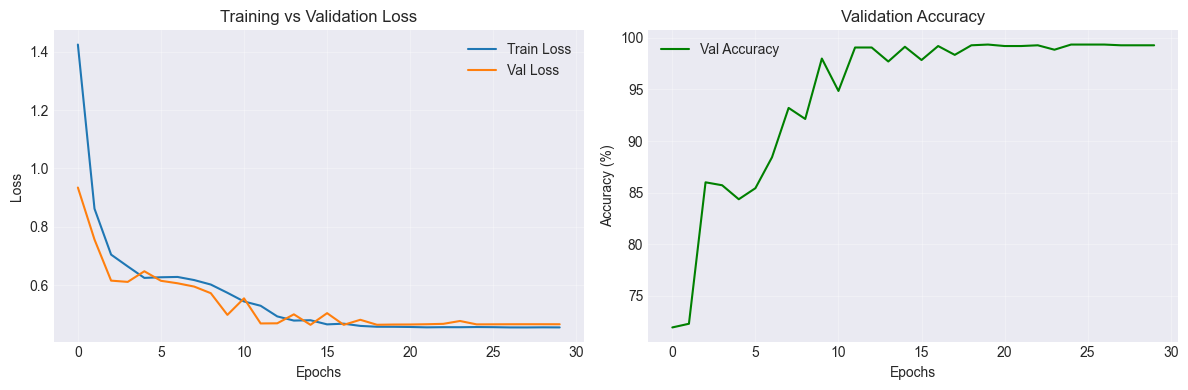

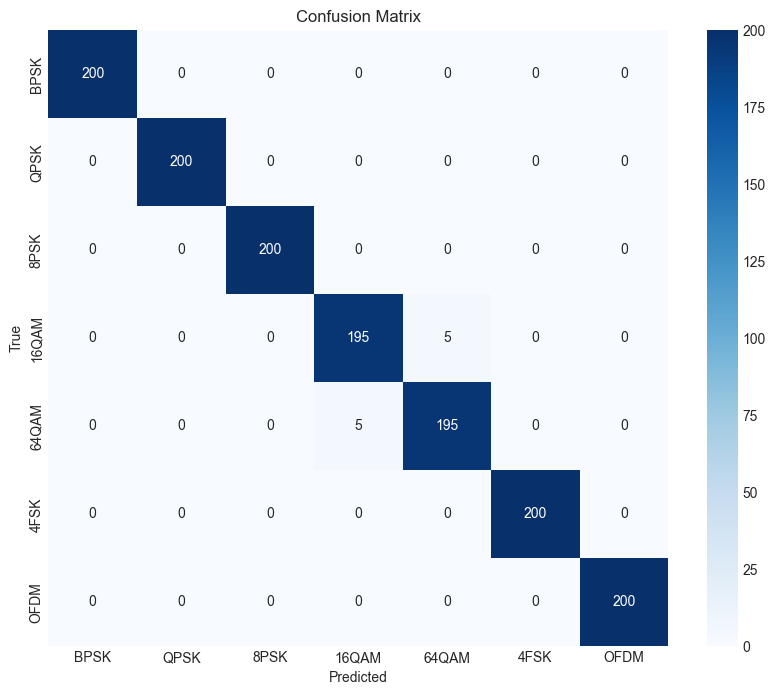


Classification Report:

              precision    recall  f1-score   support

        BPSK       1.00      1.00      1.00       200
        QPSK       1.00      1.00      1.00       200
        8PSK       1.00      1.00      1.00       200
       16QAM       0.97      0.97      0.97       200
       64QAM       0.97      0.97      0.97       200
        4FSK       1.00      1.00      1.00       200
        OFDM       1.00      1.00      1.00       200

    accuracy                           0.99      1400
   macro avg       0.99      0.99      0.99      1400
weighted avg       0.99      0.99      0.99      1400



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Plot Training History
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 2. Detailed Evaluation
def evaluate_model(model, val_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Inference loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# --- RUN EVALUATION ---

# 1. Visualize Training Curves
plot_history(history)

# 2. Run Inference & Metrics
# Make sure 'modulations' list is defined from your earlier cell
if 'modulations' not in locals():
    modulations = ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', '4FSK', 'OFDM']

evaluate_model(model_opt, val_loader, modulations)

In [ ]:
# # 1. Define Weights based on your report
# # Indexes: BPSK(0), QPSK(1), 8PSK(2), 16QAM(3), 64QAM(4), 4FSK(5), OFDM(6)
# # We give MASSIVE weight to class 4 (64QAM) and class 3 (16QAM)
# class_weights = torch.tensor([1.0, 2.0, 3.0, 3.0, 4.0, 1.0, 1.0]).to(device)

# # 2. Re-initialize Loss with Weights
# criterion_weighted = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# # 3. Load Phase 2 model (starting point)
# print("Loading Phase 2 model...")
# model_opt.load_state_dict(torch.load("best_rf_model_phase2.pth"))

# # 4. Phase 3 Training Loop (Weighted)
# print("Starting Phase 3: Weighted Fine-Tuning...")
# optimizer = torch.optim.AdamW(model_opt.parameters(), lr=0.00005, weight_decay=1e-4) # Very low LR
# scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

# for epoch in range(15): # 15 more epochs
#     model_opt.train()
#     running_loss = 0.0
    
#     for inputs, labels in train_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
        
#         optimizer.zero_grad()
        
#         with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
#             outputs = model_opt(inputs)
#             loss = criterion_weighted(outputs, labels) # <--- USING WEIGHTED LOSS
        
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
        
#         running_loss += loss.item()

#     # Quick Val Check
#     if (epoch+1) % 5 == 0:
#         print(f"Phase 3 Epoch {epoch+1}/15 complete.")

# # 5. Final Save & Eval
# torch.save(model_opt.state_dict(), "best_rf_model_final.pth")
# print("\n--- FINAL WEIGHTED EVALUATION ---")
# evaluate_model(model_opt, val_loader, modulations)

Evaluating SNR range: range(0, 26, 2)...
SNR 0dB: 79.7%
SNR 2dB: 92.0%
SNR 4dB: 95.1%
SNR 6dB: 98.6%
SNR 8dB: 99.4%
SNR 10dB: 99.7%
SNR 12dB: 99.7%
SNR 14dB: 99.7%
SNR 16dB: 99.7%
SNR 18dB: 99.7%
SNR 20dB: 100.0%
SNR 22dB: 100.0%
SNR 24dB: 99.7%


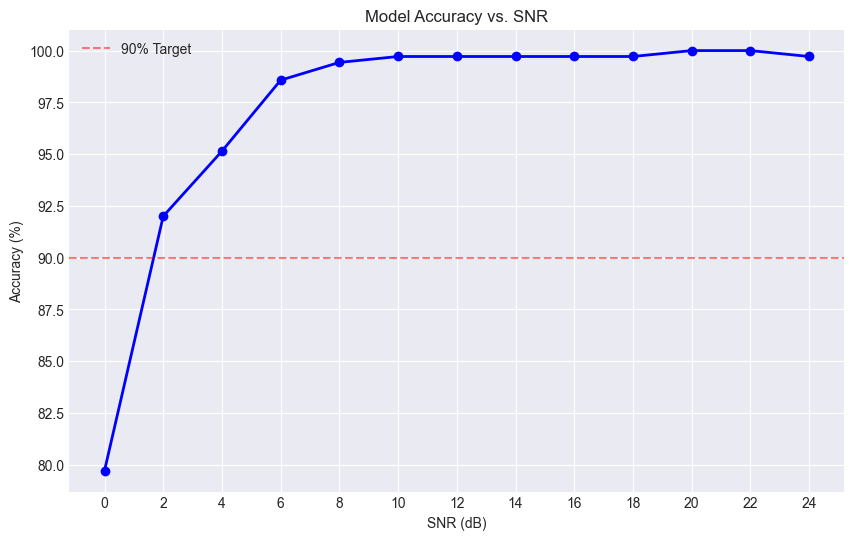

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_accuracy_by_snr(model, eng, modulations, snr_range):
    snr_accuracies = []
    
    print(f"Evaluating SNR range: {snr_range}...")
    
    model.eval()
    
    for snr in snr_range:
        correct = 0
        total = 0
        
        # Generate a mini-batch for this specific SNR
        # 50 samples per class per SNR point
        for label_idx, mod in enumerate(modulations):
            # Generate on the fly
            signal = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
            
            # Create a batch of 50
            batch_signals = []
            for _ in range(50):
                s = generate_signal(eng, mod, snr_db=snr, num_symbols=1000)
                batch_signals.append(prepare_1d_signal(s, target_length=2048))
            
            # Convert to Tensor
            X_batch = torch.FloatTensor(np.array(batch_signals)).to(device)
            y_batch = torch.LongTensor([label_idx] * 50).to(device)
            
            # Inference
            with torch.no_grad():
                outputs = model(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        acc = 100 * correct / total
        snr_accuracies.append(acc)
        print(f"SNR {snr}dB: {acc:.1f}%")
        
    return snr_accuracies

# Define SNR range to test (from noisy 0dB to clean 25dB)
snr_values = range(-5, 26, 2) 
accuracies = evaluate_accuracy_by_snr(model_opt, eng, modulations, snr_values)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(snr_values, accuracies, marker='o', linewidth=2, color='blue')
plt.title(f'Model Accuracy vs. SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.xticks(snr_values)
plt.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='90% Target')
plt.legend()
plt.show()

## Cleanup

In [ ]:
# Close MATLAB engine
eng.quit()
print("MATLAB engine closed.")

MATLAB engine closed.
